# EDA 

In [123]:
import warnings
warnings.filterwarnings("ignore")

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_parquet("../data/processed/ptf_processed.parquet")
df=df.sort_values("date")
df["ptf_TRY"] = df["ptf"]
df =df[["date","ptf_TRY"]].copy()
print(df["date"].dtype)
print(df["ptf_TRY"].dtype)
print(df.head())


datetime64[ns, pytz.FixedOffset(180)]
float64
                       date  ptf_TRY
0 2018-01-01 00:00:00+03:00   207.60
1 2018-01-01 01:00:00+03:00   205.34
2 2018-01-01 02:00:00+03:00   164.94
3 2018-01-01 03:00:00+03:00   154.52
4 2018-01-01 04:00:00+03:00   112.64


In [125]:
print(df[["date","ptf_TRY"]].isnull().sum())
df =df.set_index("date")
df = df.asfreq("h")
df.info()



date       0
ptf_TRY    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 71664 entries, 2018-01-01 00:00:00+03:00 to 2026-03-05 23:00:00+03:00
Freq: h
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ptf_TRY  71664 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


In [126]:
print(df.index.freq)
print(df.index.duplicated().sum())


<Hour>
0


In [127]:
print("Start:",df.index.min())
print("Finsih:",df.index.max())

Start: 2018-01-01 00:00:00+03:00
Finsih: 2026-03-05 23:00:00+03:00


In [128]:
pd.infer_freq(df.index[:])

'h'

In [129]:
full_range =pd.date_range(df.index.min(),df.index.max(),freq="h")
missing_hours =full_range.difference(df.index)
print(missing_hours[:20])

DatetimeIndex([], dtype='datetime64[ns, pytz.FixedOffset(180)]', freq='h')


In [130]:
df["ptf_TRY"].describe

<bound method NDFrame.describe of date
2018-01-01 00:00:00+03:00     207.60
2018-01-01 01:00:00+03:00     205.34
2018-01-01 02:00:00+03:00     164.94
2018-01-01 03:00:00+03:00     154.52
2018-01-01 04:00:00+03:00     112.64
                              ...   
2026-03-05 19:00:00+03:00    3400.00
2026-03-05 20:00:00+03:00    3400.00
2026-03-05 21:00:00+03:00    3100.00
2026-03-05 22:00:00+03:00    2999.99
2026-03-05 23:00:00+03:00    2790.00
Freq: h, Name: ptf_TRY, Length: 71664, dtype: float64>

Analysis

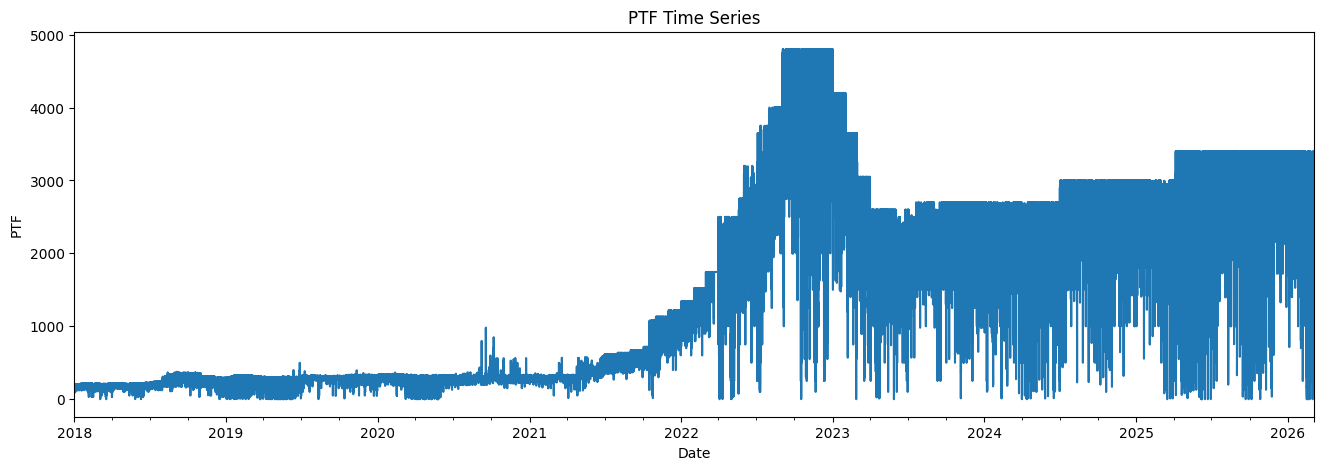

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))
df["ptf_TRY"].plot()
plt.title("PTF Time Series")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.show()

<Axes: xlabel='date'>

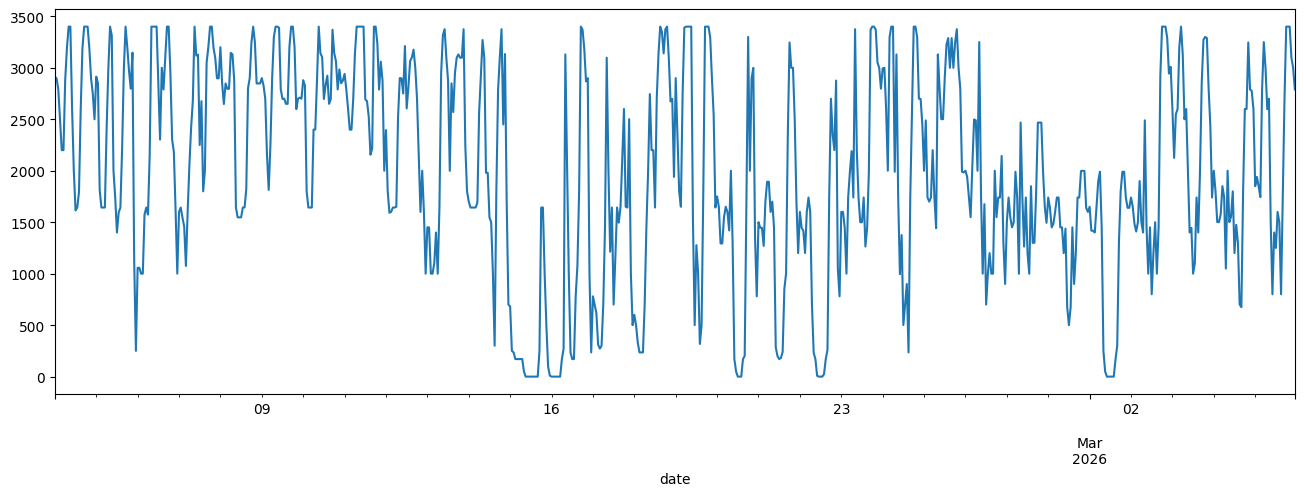

In [132]:
plt.figure(figsize=(16,5))
df["ptf_TRY"].last("30D").plot()

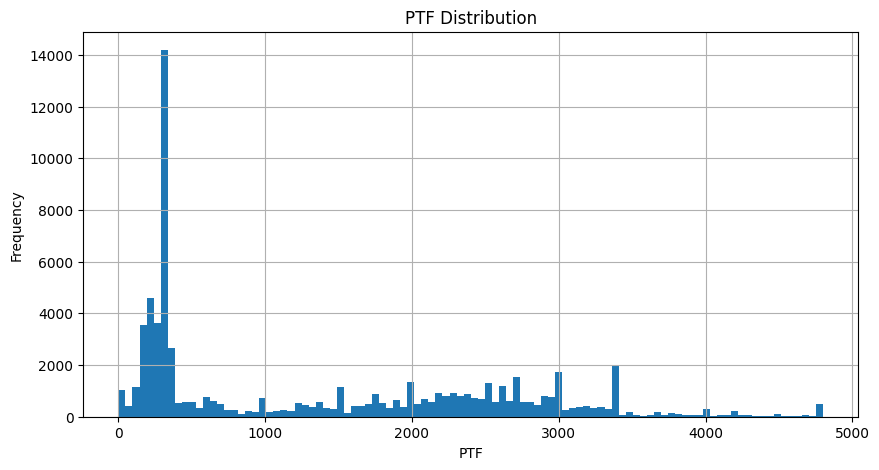

In [133]:
plt.figure(figsize=(10,5))
df["ptf_TRY"].hist(bins=100)
plt.title("PTF Distribution")
plt.xlabel("PTF")
plt.ylabel("Frequency")
plt.show()

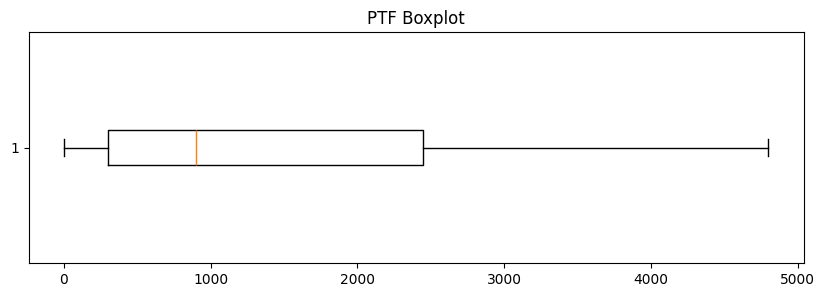

In [134]:
plt.figure(figsize=(10,3))
plt.boxplot(df["ptf_TRY"],vert=False)
plt.title("PTF Boxplot")
plt.show()

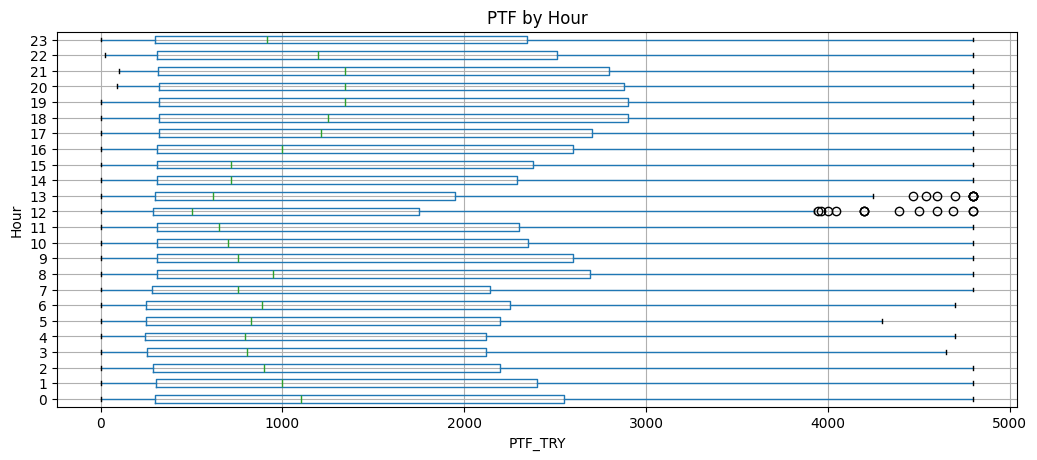

In [135]:
df_plot = df.copy()
df_plot["hour"] = df_plot.index.hour
df_plot.boxplot(column="ptf_TRY", by="hour", figsize=(12, 5), vert=False)
plt.title("PTF by Hour")
plt.suptitle("")
plt.xlabel("PTF_TRY")
plt.ylabel("Hour")
plt.show()

In [136]:
print("Skewness:", df["ptf_TRY"].skew())

Skewness: 0.6187557158550547


In [137]:
df["ptf_TRY"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01      14.9963
0.05     164.4415
0.25     303.9900
0.50     900.0000
0.75    2449.0000
0.95    3400.0000
0.99    4499.9937
Name: ptf_TRY, dtype: float64

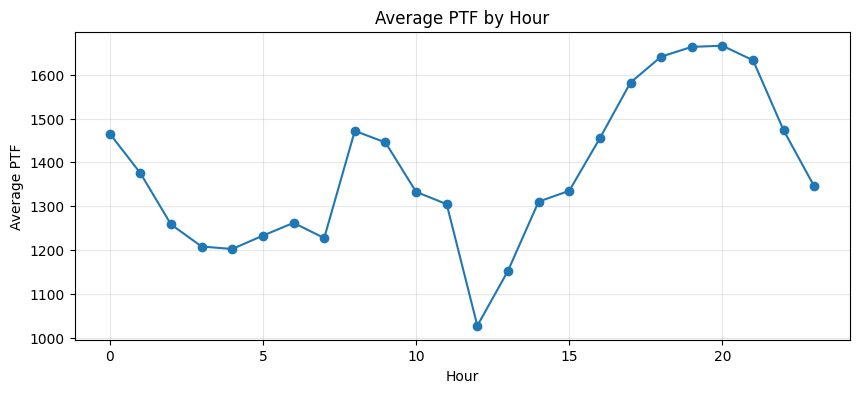

In [138]:
hourly_mean = df.groupby(df.index.hour)["ptf_TRY"].mean()

plt.figure(figsize=(10, 4))
hourly_mean.plot(marker="o")
plt.title("Average PTF by Hour")
plt.xlabel("Hour")
plt.ylabel("Average PTF")
plt.grid(True, alpha=0.3)
plt.show()

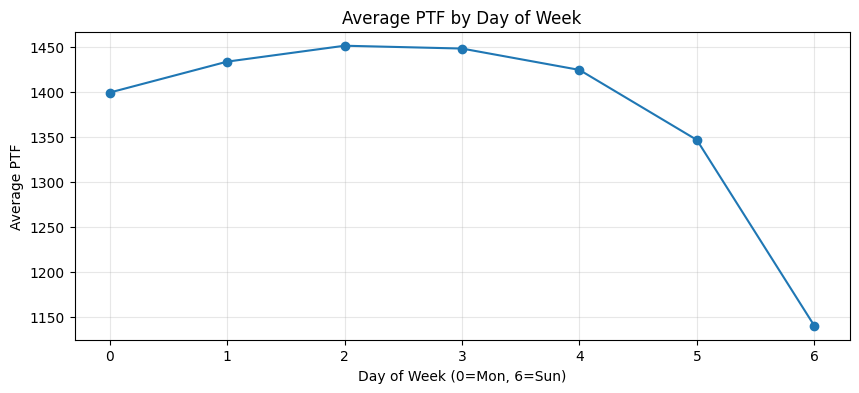

In [139]:
dow_mean = df.groupby(df.index.dayofweek)["ptf_TRY"].mean()

plt.figure(figsize=(10, 4))
dow_mean.plot(marker="o")
plt.title("Average PTF by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Average PTF")
plt.grid(True, alpha=0.3)
plt.show()

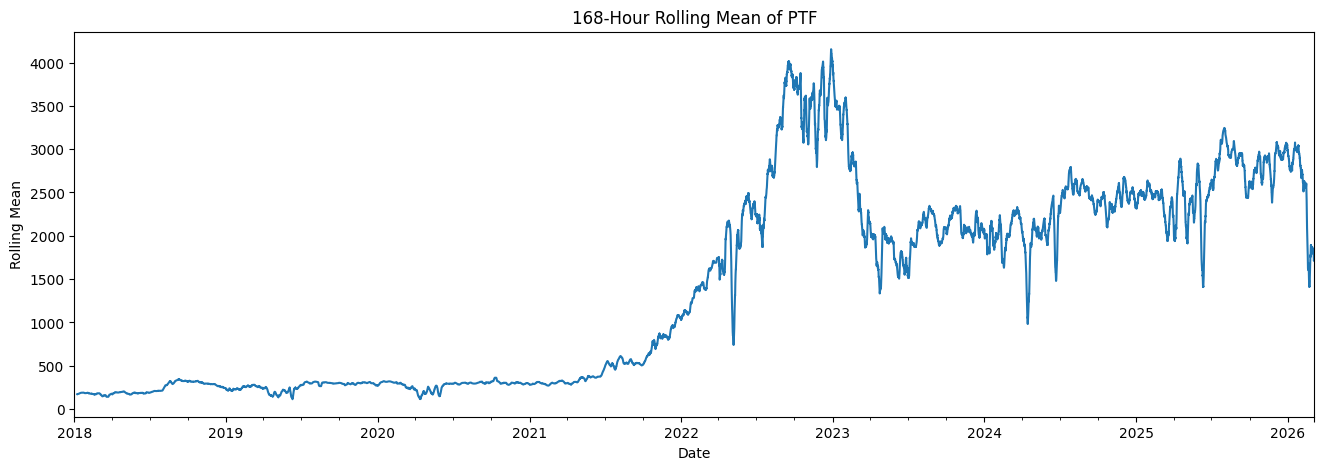

In [140]:
plt.figure(figsize=(16,5))
df["ptf_TRY"].rolling(168).mean().plot()
plt.title("168-Hour Rolling Mean of PTF")
plt.xlabel("Date")
plt.ylabel("Rolling Mean")
plt.show()

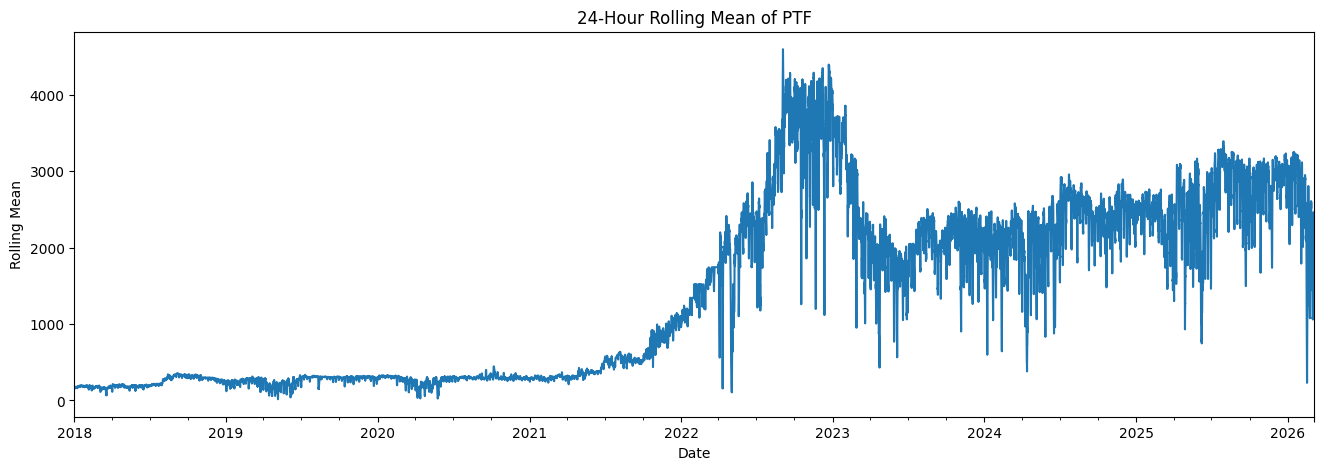

In [141]:
plt.figure(figsize=(16,5))
df["ptf_TRY"].rolling(24).mean().plot()
plt.title("24-Hour Rolling Mean of PTF")
plt.xlabel("Date")
plt.ylabel("Rolling Mean")
plt.show()

In [142]:
df_eda = df.copy()
df_eda["lag_24"] = df_eda["ptf_TRY"].shift(24)
df_eda["lag_168"] = df_eda["ptf_TRY"].shift(168)

print(df_eda[["ptf_TRY", "lag_24", "lag_168"]].corr())

          ptf_TRY    lag_24   lag_168
ptf_TRY  1.000000  0.927092  0.927506
lag_24   0.927092  1.000000  0.902486
lag_168  0.927506  0.902486  1.000000


<Figure size 1400x400 with 0 Axes>

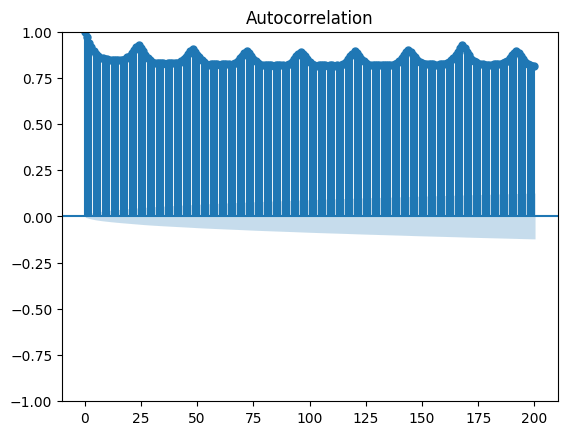

In [143]:
plt.figure(figsize=(14,4))
sm.graphics.tsa.plot_acf(df["ptf_TRY"],lags=200)
plt.show()

In [144]:
print("En yüksek 10 değer:")
print(df.nlargest(10, "ptf_TRY"))

En yüksek 10 değer:
                           ptf_TRY
date                              
2022-09-02 09:00:00+03:00   4800.0
2022-09-02 11:00:00+03:00   4800.0
2022-09-02 14:00:00+03:00   4800.0
2022-09-02 15:00:00+03:00   4800.0
2022-09-02 16:00:00+03:00   4800.0
2022-09-02 17:00:00+03:00   4800.0
2022-09-02 18:00:00+03:00   4800.0
2022-09-02 19:00:00+03:00   4800.0
2022-09-02 20:00:00+03:00   4800.0
2022-09-02 21:00:00+03:00   4800.0


In [145]:
#print("En düşük 10 değer:")
#print(df.nsmallest(10, "ptf_TRY"))

a=df[df["ptf_TRY"] == 0]
print(a)

                           ptf_TRY
date                              
2018-03-18 12:00:00+03:00      0.0
2018-03-18 13:00:00+03:00      0.0
2018-03-18 14:00:00+03:00      0.0
2018-03-18 15:00:00+03:00      0.0
2019-02-17 09:00:00+03:00      0.0
...                            ...
2026-03-01 10:00:00+03:00      0.0
2026-03-01 11:00:00+03:00      0.0
2026-03-01 12:00:00+03:00      0.0
2026-03-01 13:00:00+03:00      0.0
2026-03-01 14:00:00+03:00      0.0

[176 rows x 1 columns]


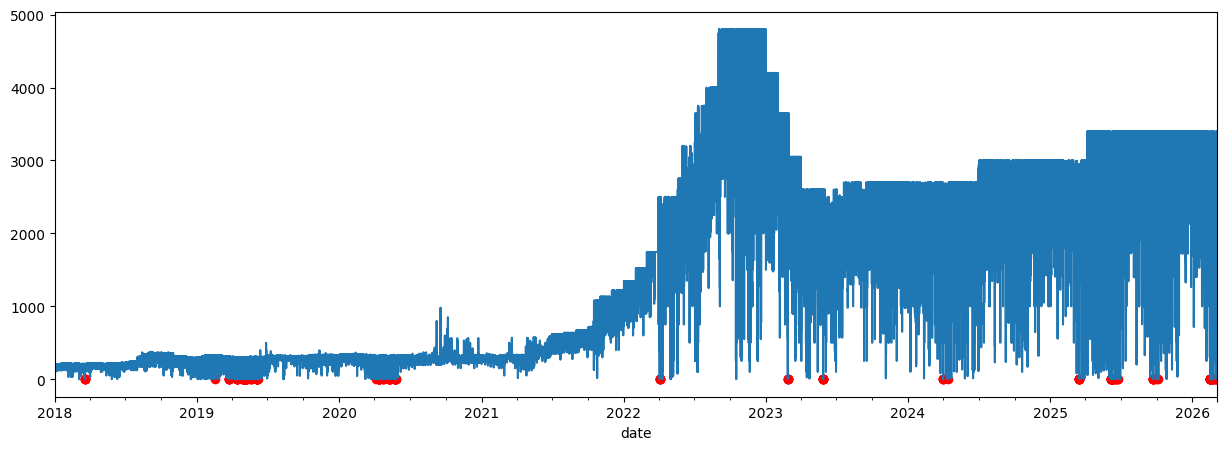

In [147]:
plt.figure(figsize=(15,5))
df["ptf_TRY"].plot()

plt.scatter(
    df[df["ptf_TRY"]==0].index,
    df[df["ptf_TRY"]==0]["ptf_TRY"],
    color="red"
)

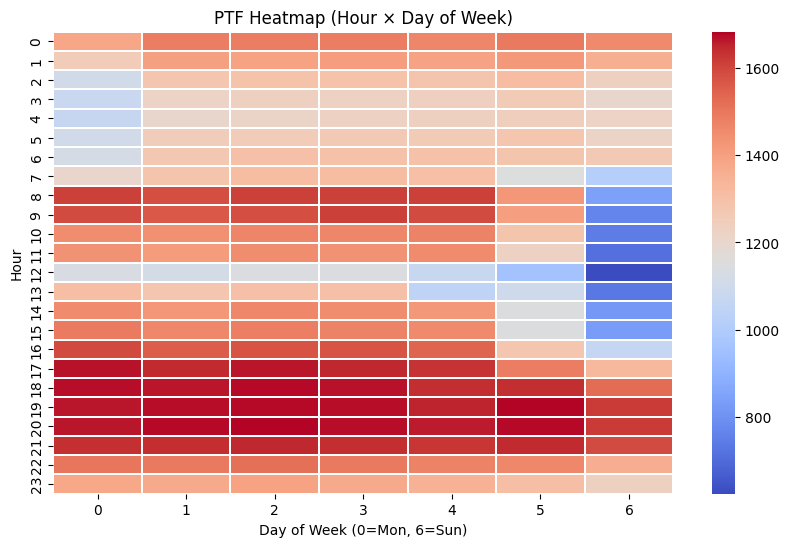

In [156]:
import seaborn as sns

df_heat = df.copy()

df_heat["hour"] = df_heat.index.hour
df_heat["day_of_week"] = df_heat.index.dayofweek

heatmap_data = df_heat.pivot_table(
    values="ptf_TRY",
    index="hour",
    columns="day_of_week",
    aggfunc="mean"
)

heatmap_data

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=False,
    linewidths=0.3
)
heatmap_data = df_heat.pivot_table(
    values="ptf_TRY",
    index="hour",
    columns="day_of_week",
    aggfunc="mean"
)

heatmap_data
plt.title("PTF Heatmap (Hour × Day of Week)")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Hour")

plt.show()

## EDA Summary

Data Range:
2018 - 2026

Missing timestamps:
0

Zero price count:
176

Observations:
- Strong hourly seasonality
- Weekday / weekend difference
- Significant volatility increase after 2022
- Strong lag relationships at 24h and 168h

Candidate Features:
hour
day_of_week
is_weekend
month
lag_24
lag_168
rolling_mean_24
rolling_mean_168